# Exploratory Data Analysis of the Podcast Listening Time Kaggle playground

In [1]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from modules.plotting import *

DATA_PATH = "./data/"
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

## Load and Summaries

In [2]:
train = pl.read_csv(DATA_PATH + "train.csv")
test = pl.read_csv(DATA_PATH + "test.csv")

In [3]:
train.schema

Schema([('id', Int64),
        ('Podcast_Name', String),
        ('Episode_Title', String),
        ('Episode_Length_minutes', Float64),
        ('Genre', String),
        ('Host_Popularity_percentage', Float64),
        ('Publication_Day', String),
        ('Publication_Time', String),
        ('Guest_Popularity_percentage', Float64),
        ('Number_of_Ads', Float64),
        ('Episode_Sentiment', String),
        ('Listening_Time_minutes', Float64)])

We may immediately drop the ID

In [4]:
train.drop_in_place("id")

id
i64
0
1
2
3
4
…
749995
749996
749997


In [5]:
train.null_count()

Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,87093,0,0,0,0,146030,1,0,0


Seems the data is split into a 75/25 ratio. The training data does contain several missing values on Episode_Length_Minutes and Guest_Popularity_Percentage columns which will have to be dealt with. The prediction target is Listening_Time_Minutes.

In [6]:
train.describe()

statistic,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
str,str,str,f64,str,f64,str,str,f64,f64,str,f64
"""count""","""750000""","""750000""",662907.0,"""750000""",750000.0,"""750000""","""750000""",603970.0,749999.0,"""750000""",750000.0
"""null_count""","""0""","""0""",87093.0,"""0""",0.0,"""0""","""0""",146030.0,1.0,"""0""",0.0
"""mean""",null,null,64.504738,null,59.859901,null,null,52.236449,1.348855,null,45.437406
"""std""",null,null,32.969603,null,22.873098,null,null,28.451241,1.15113,null,27.138306
"""min""","""Athlete's Arena""","""Episode 1""",0.0,"""Business""",1.3,"""Friday""","""Afternoon""",0.0,0.0,"""Negative""",0.0
"""25%""",null,null,35.73,null,39.41,null,null,28.38,0.0,null,23.17835
"""50%""",null,null,63.84,null,60.05,null,null,53.58,1.0,null,43.37946
"""75%""",null,null,94.07,null,79.53,null,null,76.6,2.0,null,64.81158
"""max""","""World Watch""","""Episode 99""",325.24,"""True Crime""",119.46,"""Wednesday""","""Night""",119.91,103.91,"""Positive""",119.97


A mean of 45, located to the right of a median of 43, indicates some right-skewness in the target data

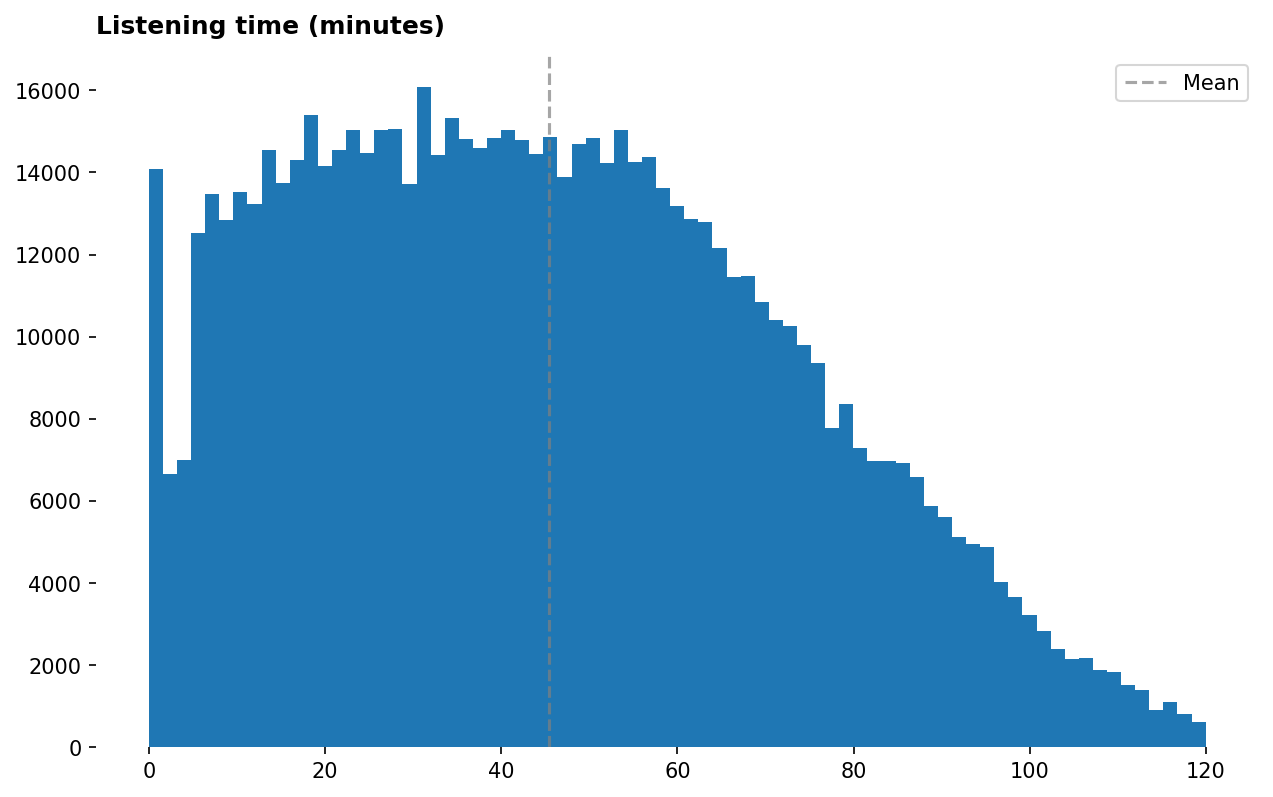

In [7]:
histogram(train["Listening_Time_minutes"], "Listening time (minutes)", train["Listening_Time_minutes"].mean())

## Correlations

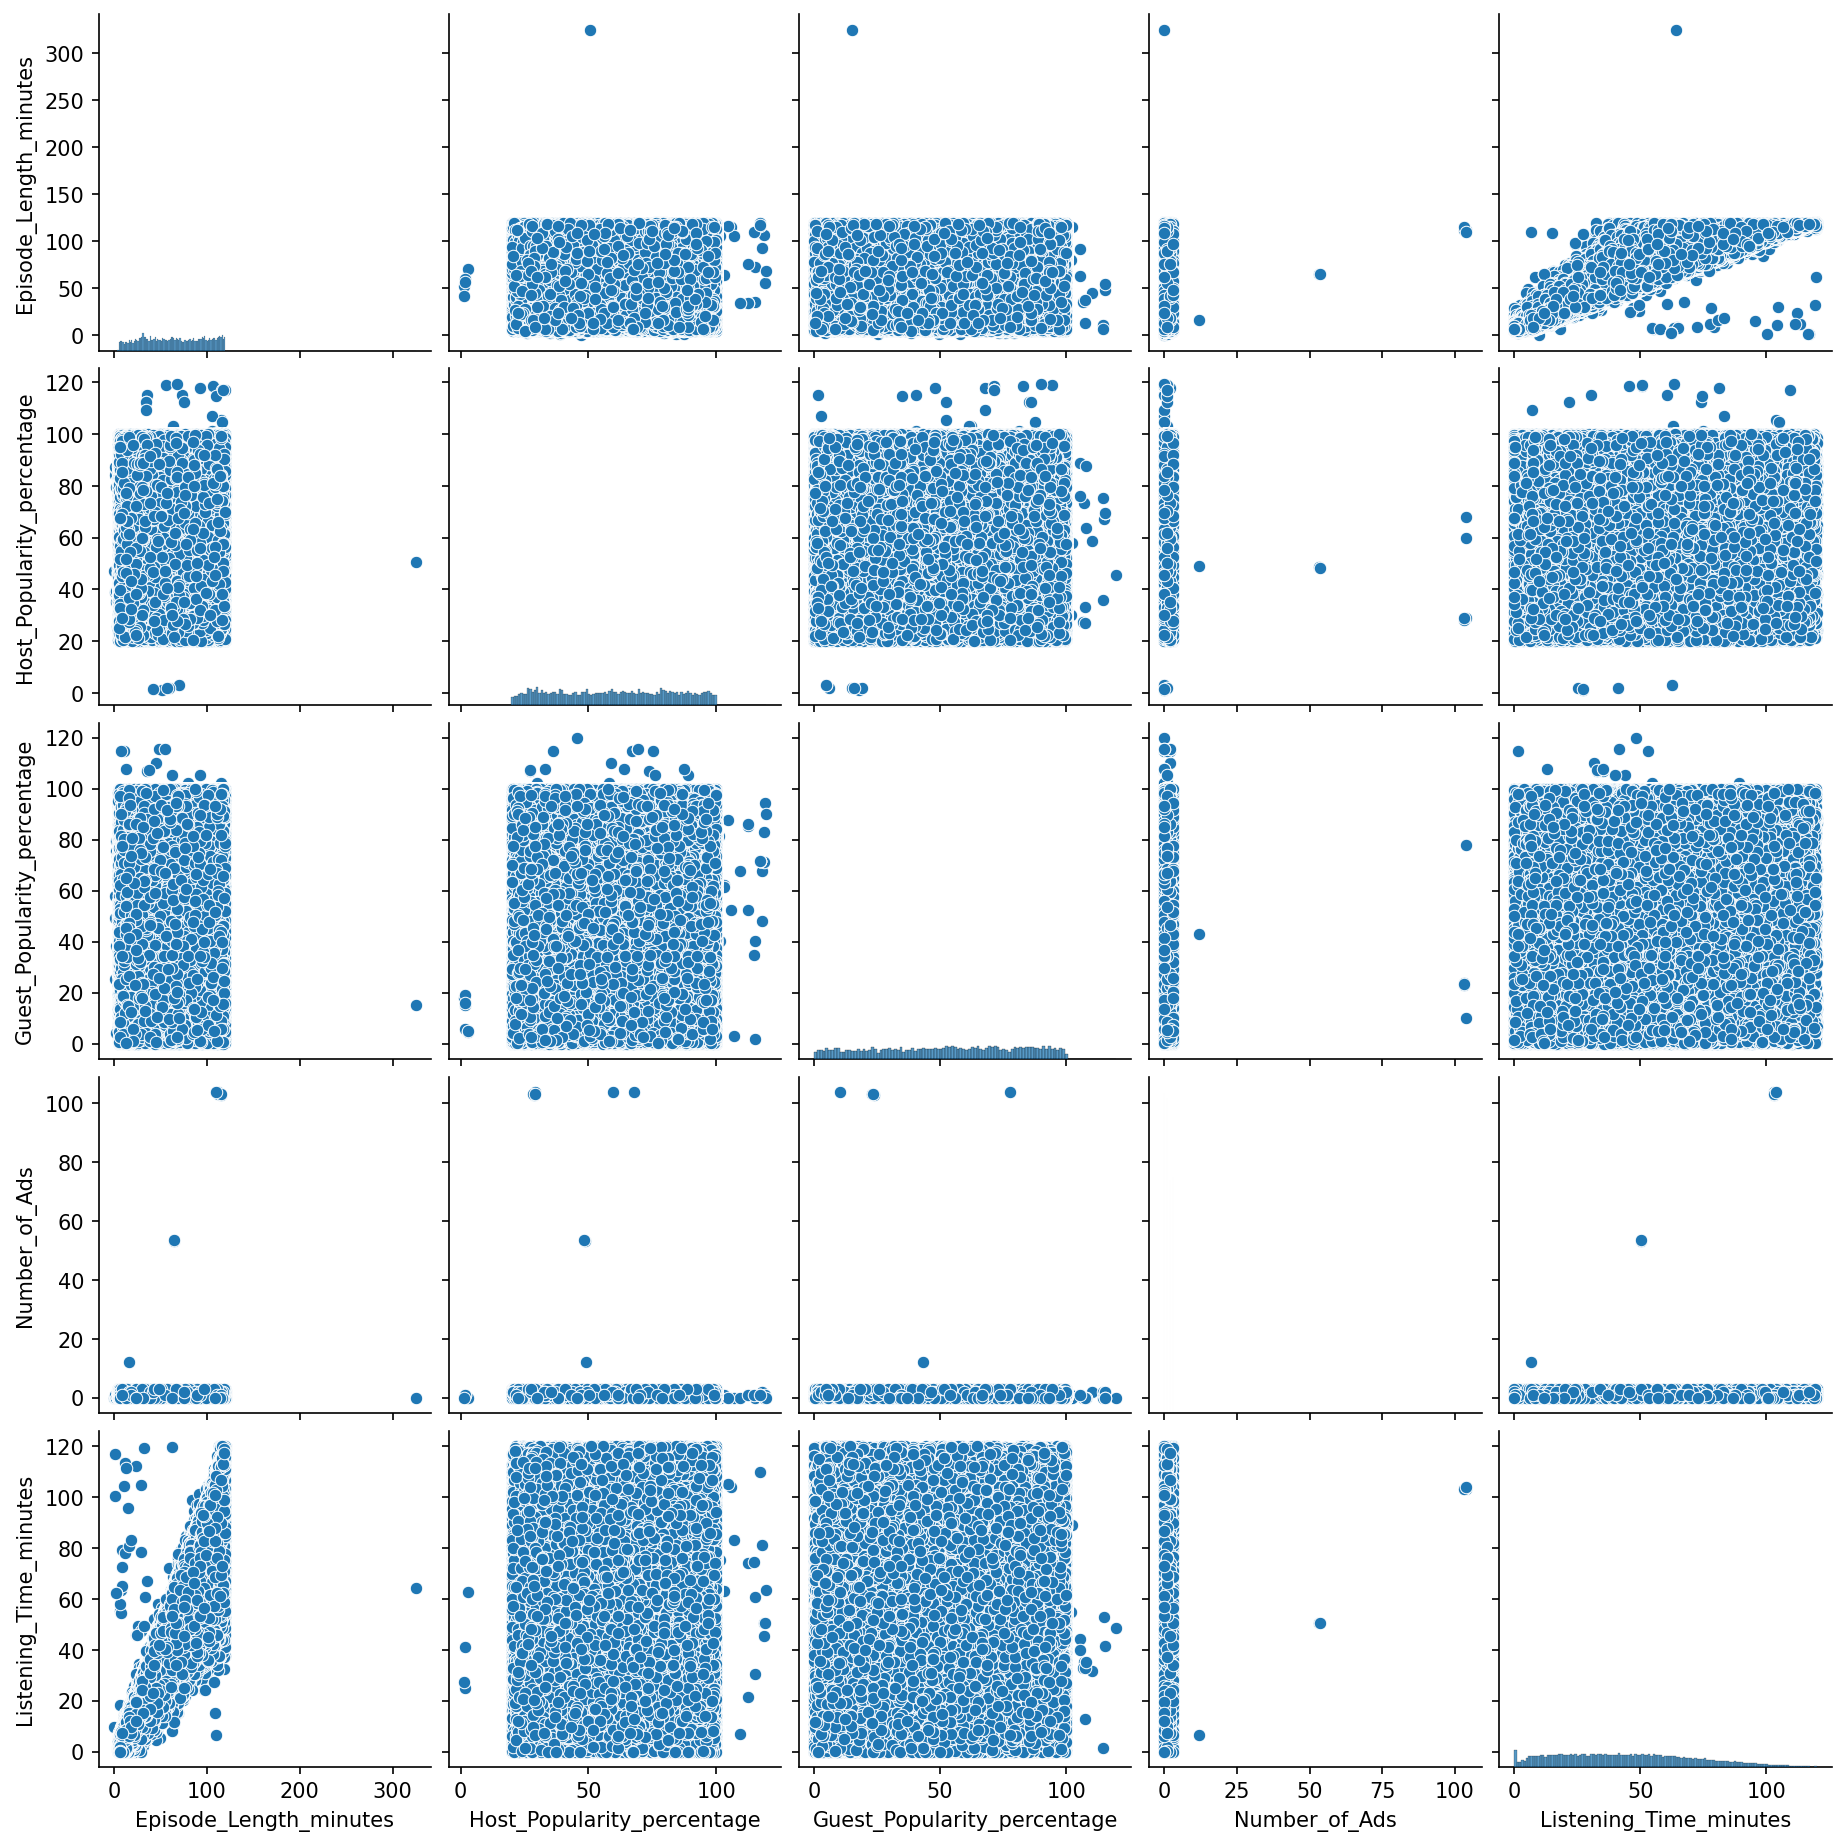

In [8]:
sns.pairplot(train.to_pandas())

In [9]:
numeric_dtype_cols = train.select(pl.col(pl.NUMERIC_DTYPES))
numeric_dtype_cols

/var/folders/jq/tdq0h8rj1zdbxsbs18vhfp0h0000gp/T/ipykernel_35832/440786485.py:1: DeprecationWarning: `NUMERIC_DTYPES` is deprecated. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  numeric_dtype_cols = train.select(pl.col(pl.NUMERIC_DTYPES))


Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
f64,f64,f64,f64,f64
null,74.81,null,0.0,31.41998
119.8,66.95,75.95,2.0,88.01241
73.9,69.97,8.97,0.0,44.92531
67.17,57.22,78.7,2.0,46.27824
110.51,80.07,58.68,3.0,75.61031
…,…,…,…,…
75.66,69.36,null,0.0,56.87058
75.75,35.21,null,2.0,45.46242
30.98,78.58,84.89,0.0,15.26


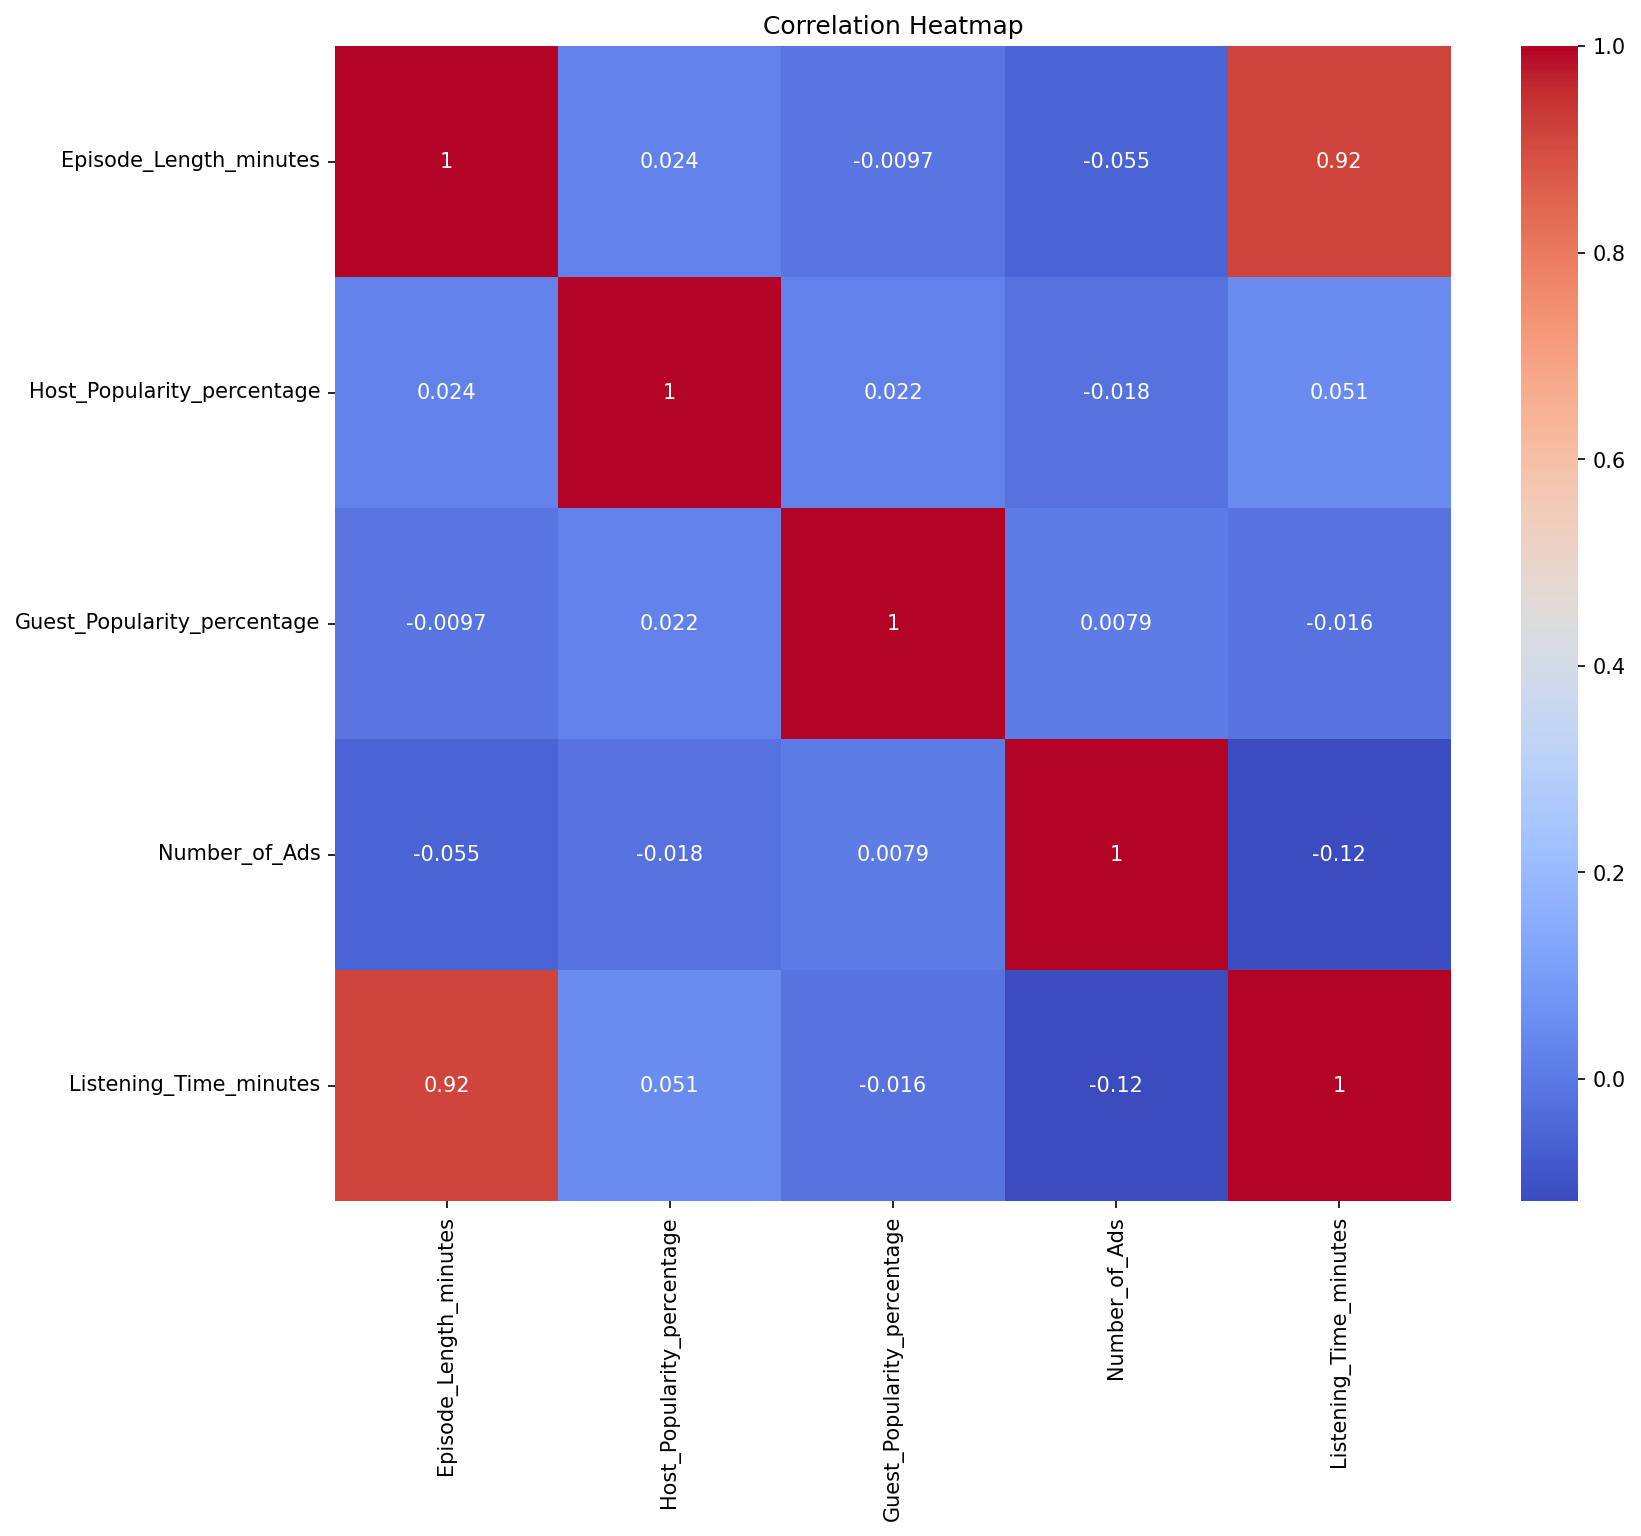

In [10]:
corr = numeric_dtype_cols.to_pandas().corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True
)
plt.title("Correlation Heatmap")
plt.show()


By the pairplot, it might seem to be a correlation between Listening_Time_minutes and Episode_Length_minutes. It's also evident that there is an outlier of episode length and outliers in number of ads

## Correlation between Episode_Length and Listening Time (no outlier)

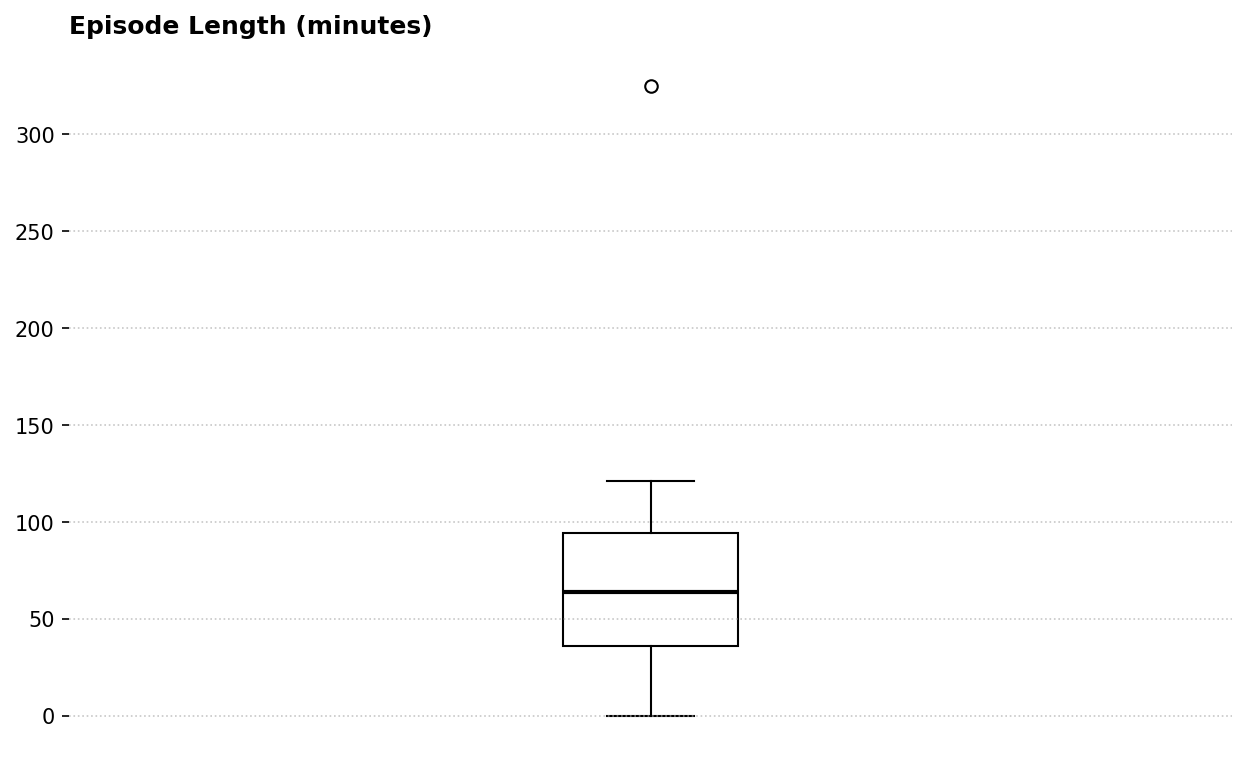

In [11]:
boxplot(train["Episode_Length_minutes"].drop_nulls(), "Episode Length (minutes)")

There does in fact appear to have an outlier in episode length. Let's verify the correlation to Listening Time after removing this outlier entry

In [12]:
# ep_length_no_outlier = train[train["Episode_Length_minutes"] < 300]
ep_length_no_outlier = train.filter(pl.col("Episode_Length_minutes") < 300)
type(ep_length_no_outlier)

polars.dataframe.frame.DataFrame

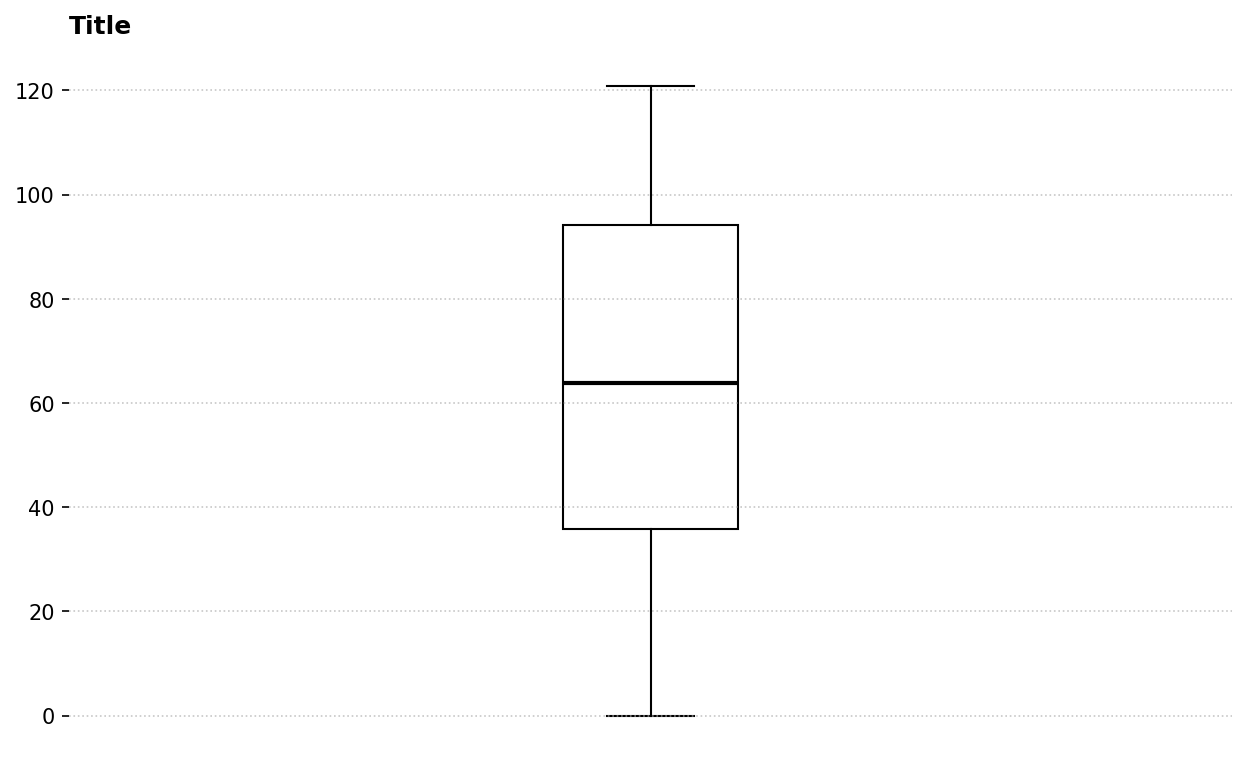

In [13]:
boxplot(ep_length_no_outlier["Episode_Length_minutes"].drop_nulls())

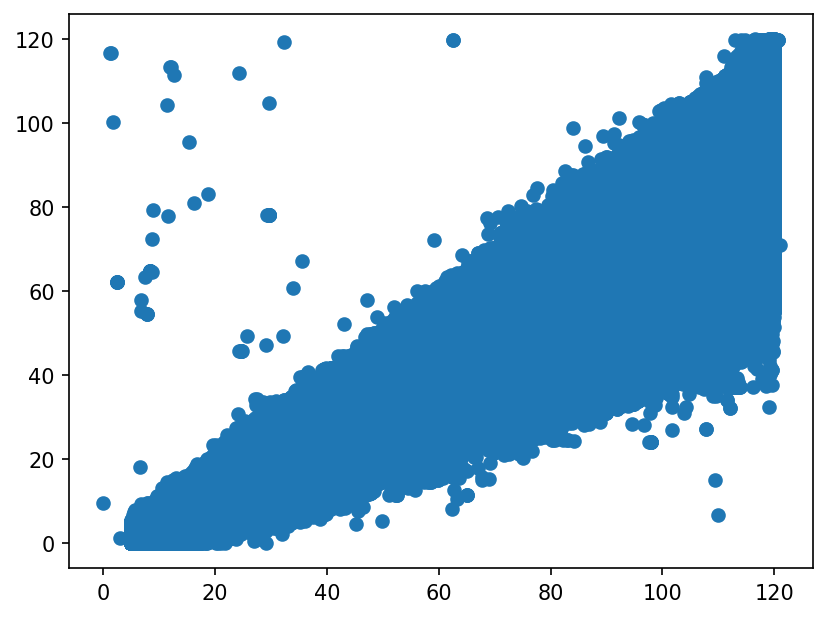

In [14]:
plt.scatter(ep_length_no_outlier["Episode_Length_minutes"], ep_length_no_outlier["Listening_Time_minutes"])

/var/folders/jq/tdq0h8rj1zdbxsbs18vhfp0h0000gp/T/ipykernel_35832/4116284536.py:1: DeprecationWarning: `NUMERIC_DTYPES` is deprecated. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  epl_no_outliers_numeric = ep_length_no_outlier.select(pl.col(pl.NUMERIC_DTYPES))


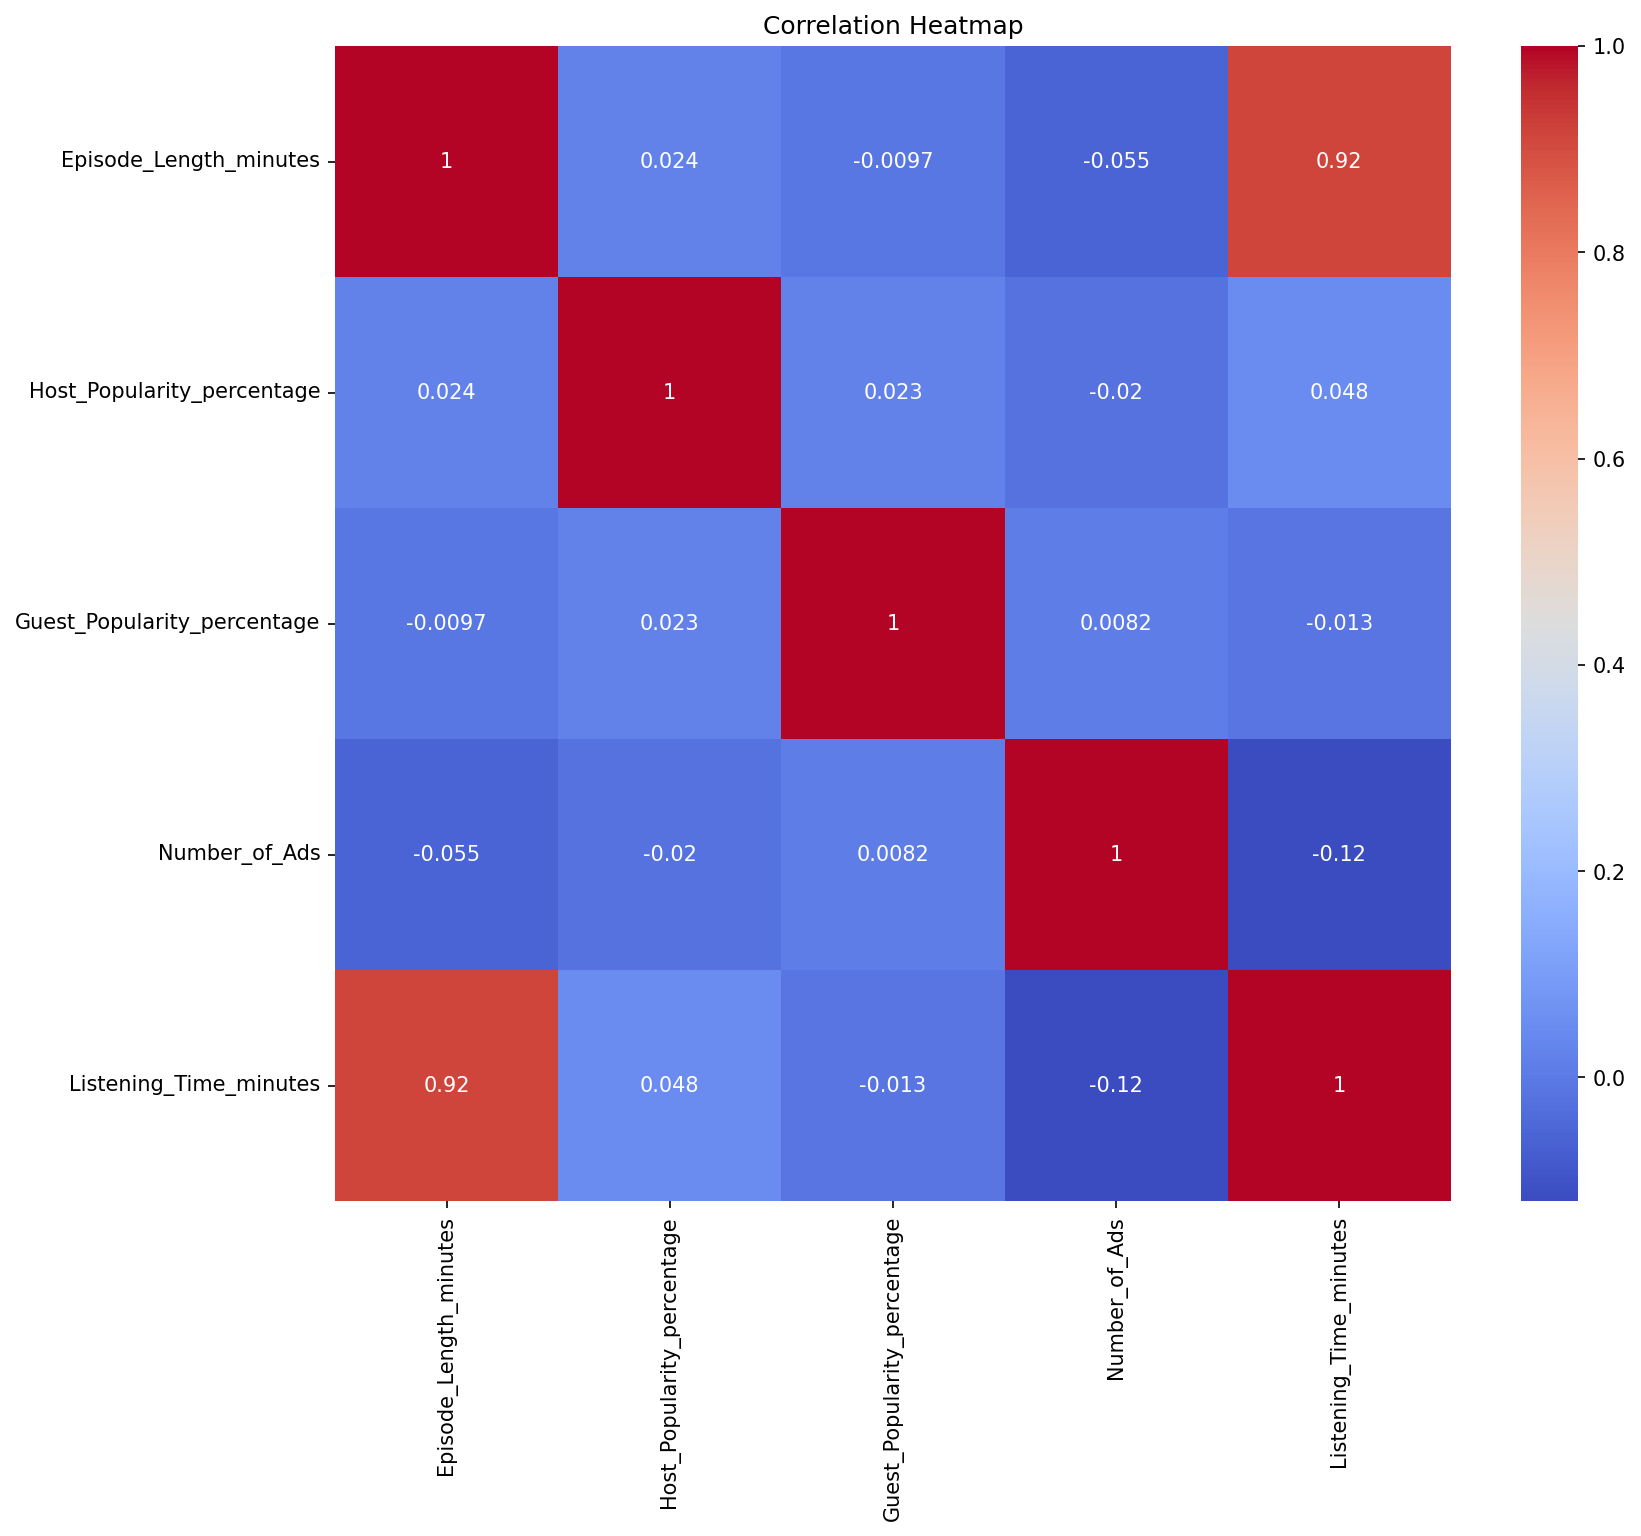

In [15]:
epl_no_outliers_numeric = ep_length_no_outlier.select(pl.col(pl.NUMERIC_DTYPES))
corr_epl_no_outlier = epl_no_outliers_numeric.to_pandas().corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_epl_no_outlier,
    cmap="coolwarm",
    annot=True
)
plt.title("Correlation Heatmap")
plt.show()

Removing the outlier maintains the correlation of .92

## Correlation between Number of Ads and Listening Time (no outlier)

Let us also verify the correlation between listening time and number of ads when removing the Ads outliers

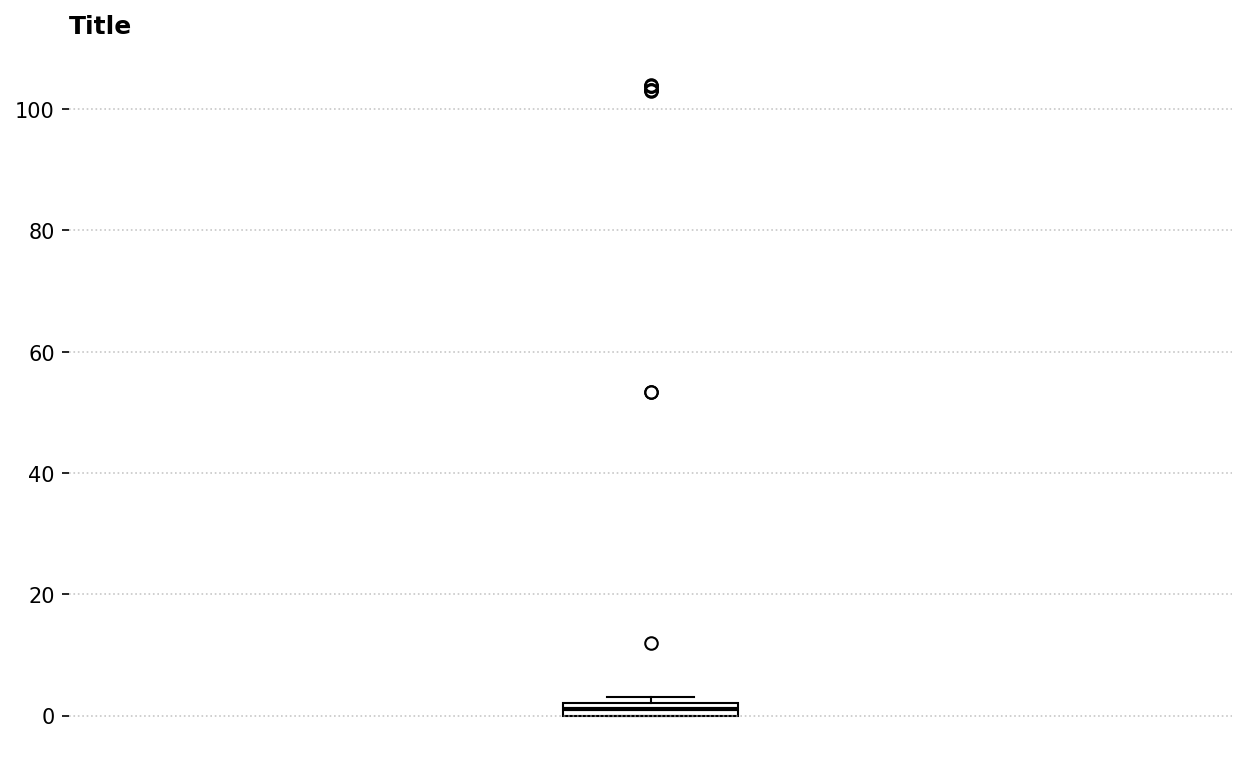

In [16]:
boxplot(train["Number_of_Ads"].drop_nulls())

Here, several outliers pull the distribution to the higher end

In [17]:

q1 = train.select(pl.col("Number_of_Ads").quantile(0.25)).item()
q3 = train.select(pl.col("Number_of_Ads").quantile(0.75)).item()
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

n_of_ads_no_outliers = train.filter(pl.col("Number_of_Ads") <= upper_fence)
n_of_ads_no_outliers.describe()

statistic,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
str,str,str,f64,str,f64,str,str,f64,f64,str,f64
"""count""","""749990""","""749990""",662897.0,"""749990""",749990.0,"""749990""","""749990""",603962.0,749990.0,"""749990""",749990.0
"""null_count""","""0""","""0""",87093.0,"""0""",0.0,"""0""","""0""",146028.0,0.0,"""0""",0.0
"""mean""",null,null,64.504419,null,59.860145,null,null,52.236596,1.347885,null,45.43701
"""std""",null,null,32.969462,null,22.873093,null,null,28.451265,1.110968,null,27.137942
"""min""","""Athlete's Arena""","""Episode 1""",0.0,"""Business""",1.3,"""Friday""","""Afternoon""",0.0,0.0,"""Negative""",0.0
"""25%""",null,null,35.73,null,39.41,null,null,28.38,0.0,null,23.17835
"""50%""",null,null,63.84,null,60.05,null,null,53.58,1.0,null,43.37946
"""75%""",null,null,94.07,null,79.53,null,null,76.6,2.0,null,64.81158
"""max""","""World Watch""","""Episode 99""",325.24,"""True Crime""",119.46,"""Wednesday""","""Night""",119.91,3.0,"""Positive""",119.97


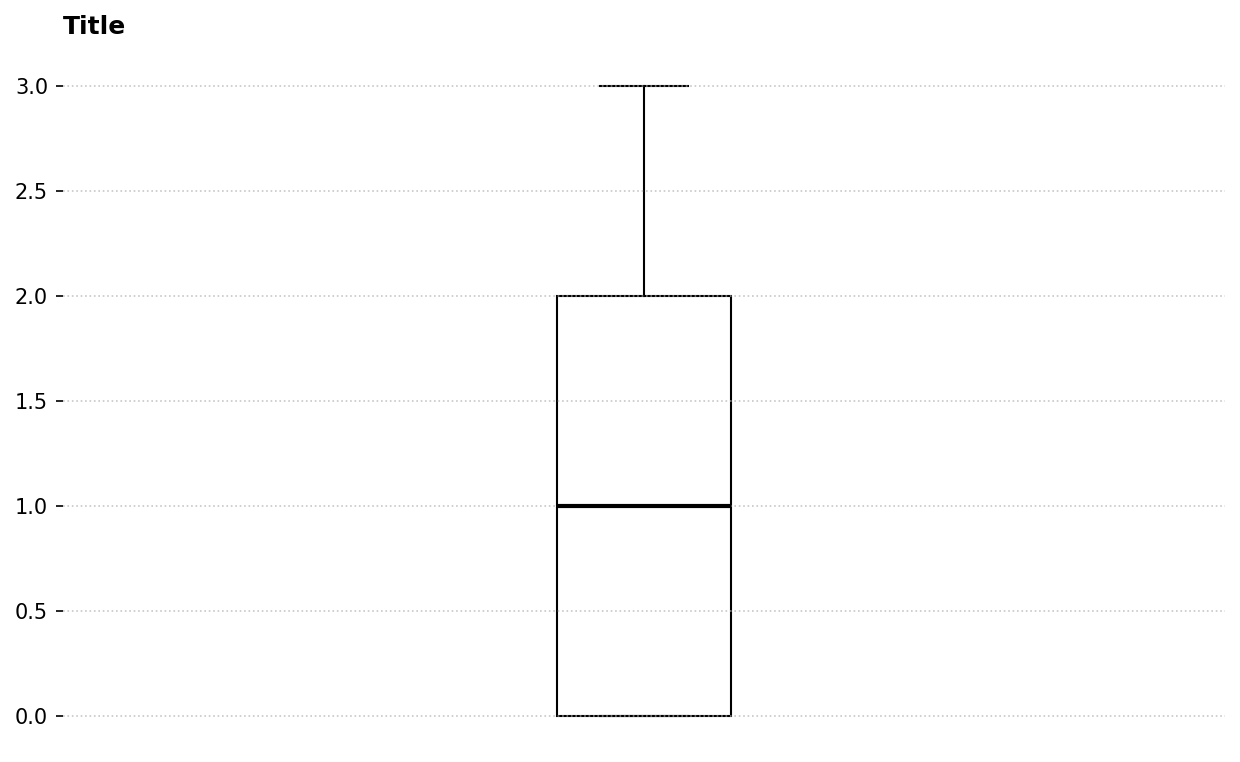

In [18]:
boxplot(n_of_ads_no_outliers["Number_of_Ads"].drop_nulls())

/var/folders/jq/tdq0h8rj1zdbxsbs18vhfp0h0000gp/T/ipykernel_35832/895867369.py:1: DeprecationWarning: `NUMERIC_DTYPES` is deprecated. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  nofads_no_outliers_numeric = n_of_ads_no_outliers.select(pl.col(pl.NUMERIC_DTYPES))


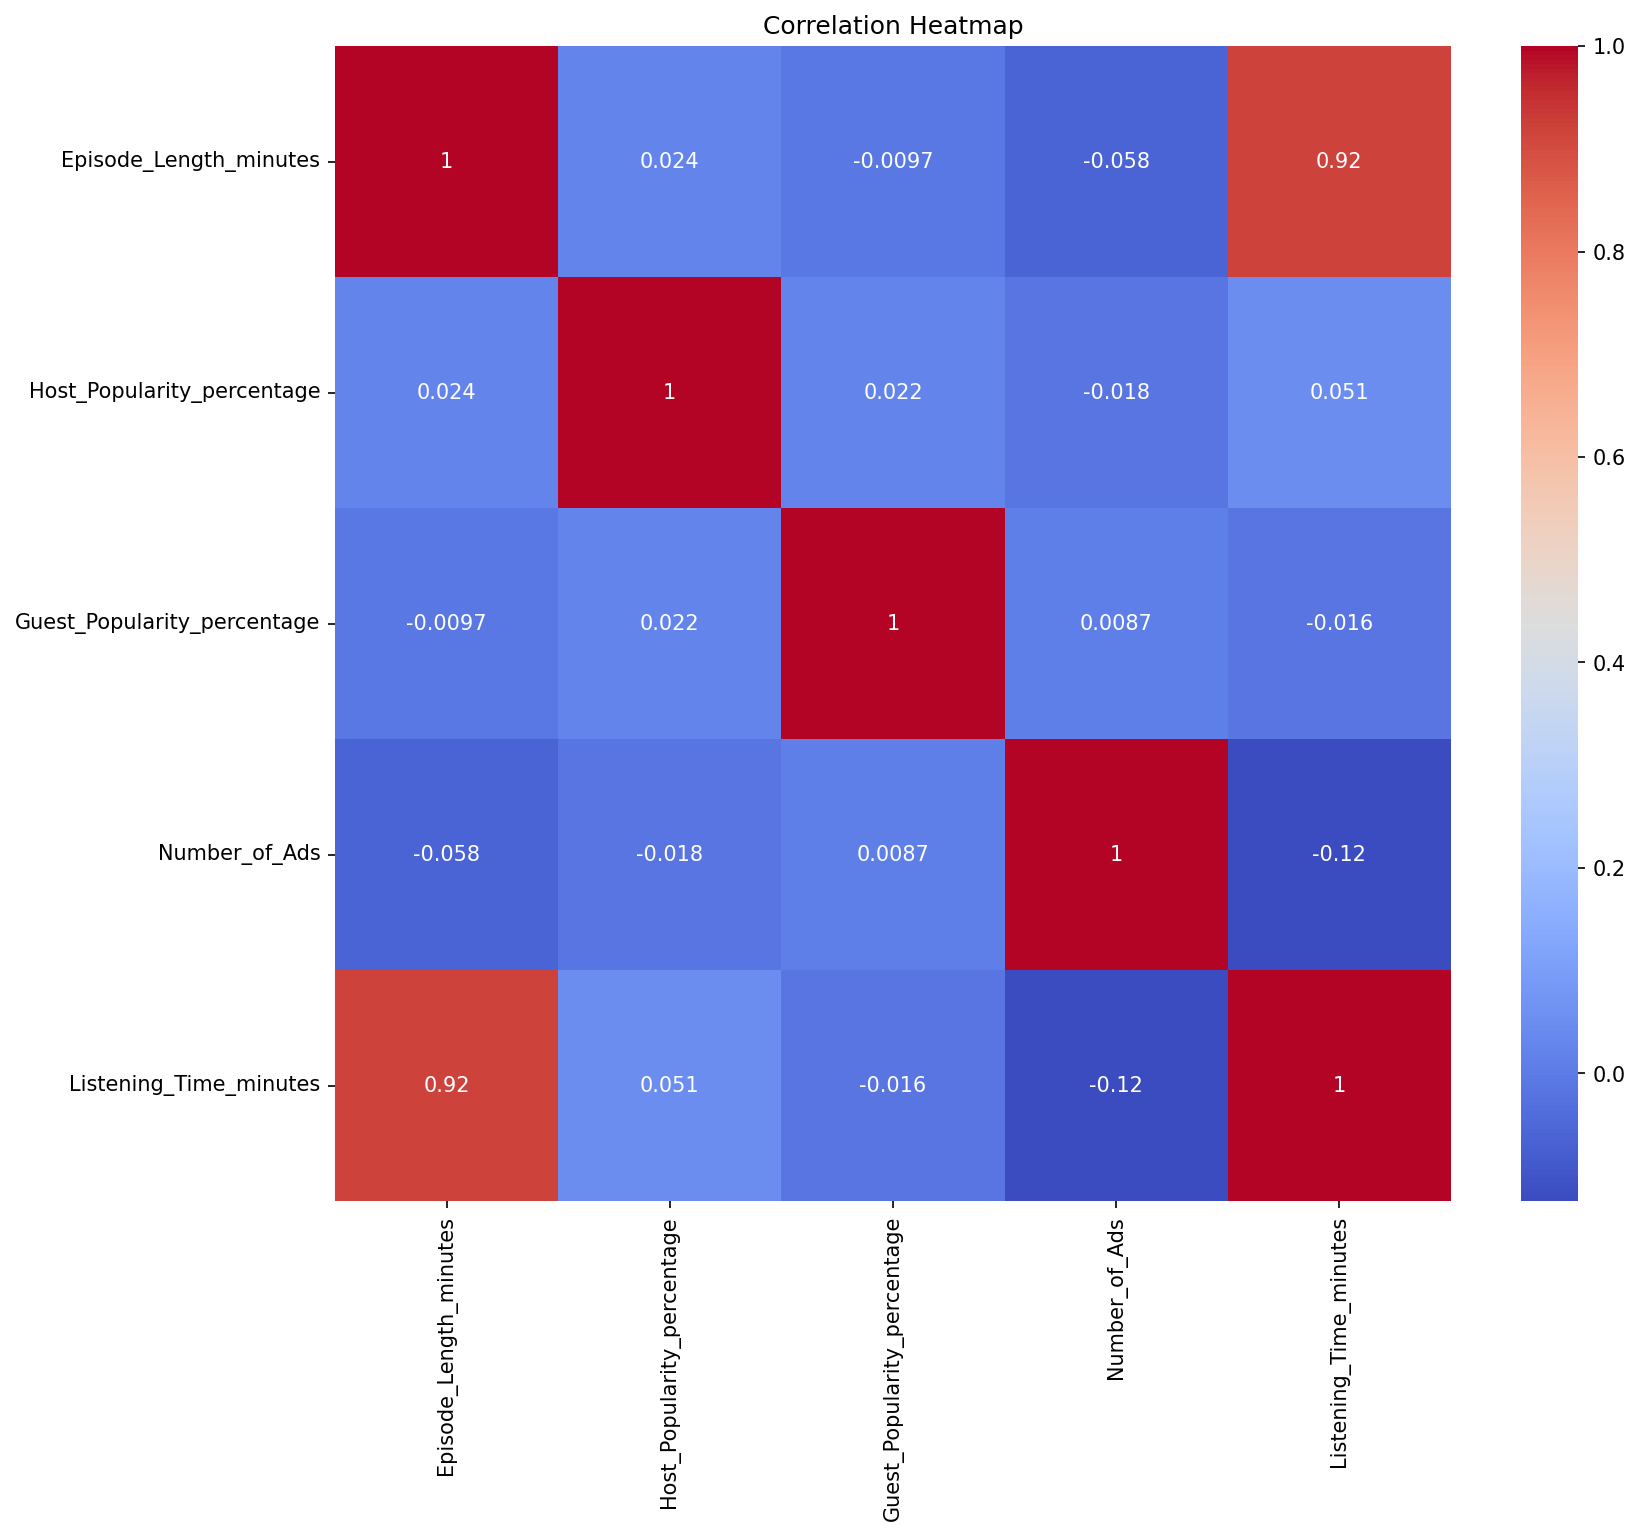

In [19]:
nofads_no_outliers_numeric = n_of_ads_no_outliers.select(pl.col(pl.NUMERIC_DTYPES))
corr_nofads_no_outliers = nofads_no_outliers_numeric.to_pandas().corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_nofads_no_outliers,
    cmap="coolwarm",
    annot=True
)
plt.title("Correlation Heatmap")
plt.show()

Removing outliers has little effect on the correlation between number of ads and listening time as well

## Listening Time per Genre

In [20]:
train["Genre"].n_unique()

10

In [21]:
train["Genre"].unique_counts()

Genre
u32
85059
81453
49100
86256
71416
63385
62743
87606
80521


In [22]:
genres_and_counts = train.group_by("Genre").mean()[["Genre", "Listening_Time_minutes"]]
genres_and_counts

Genre,Listening_Time_minutes
str,f64
"""Comedy""",44.426441
"""Business""",45.538151
"""News""",44.406144
"""Lifestyle""",45.523117
"""Music""",46.578394
"""Technology""",45.634749
"""True Crime""",46.042507
"""Education""",45.73664
"""Sports""",44.935722


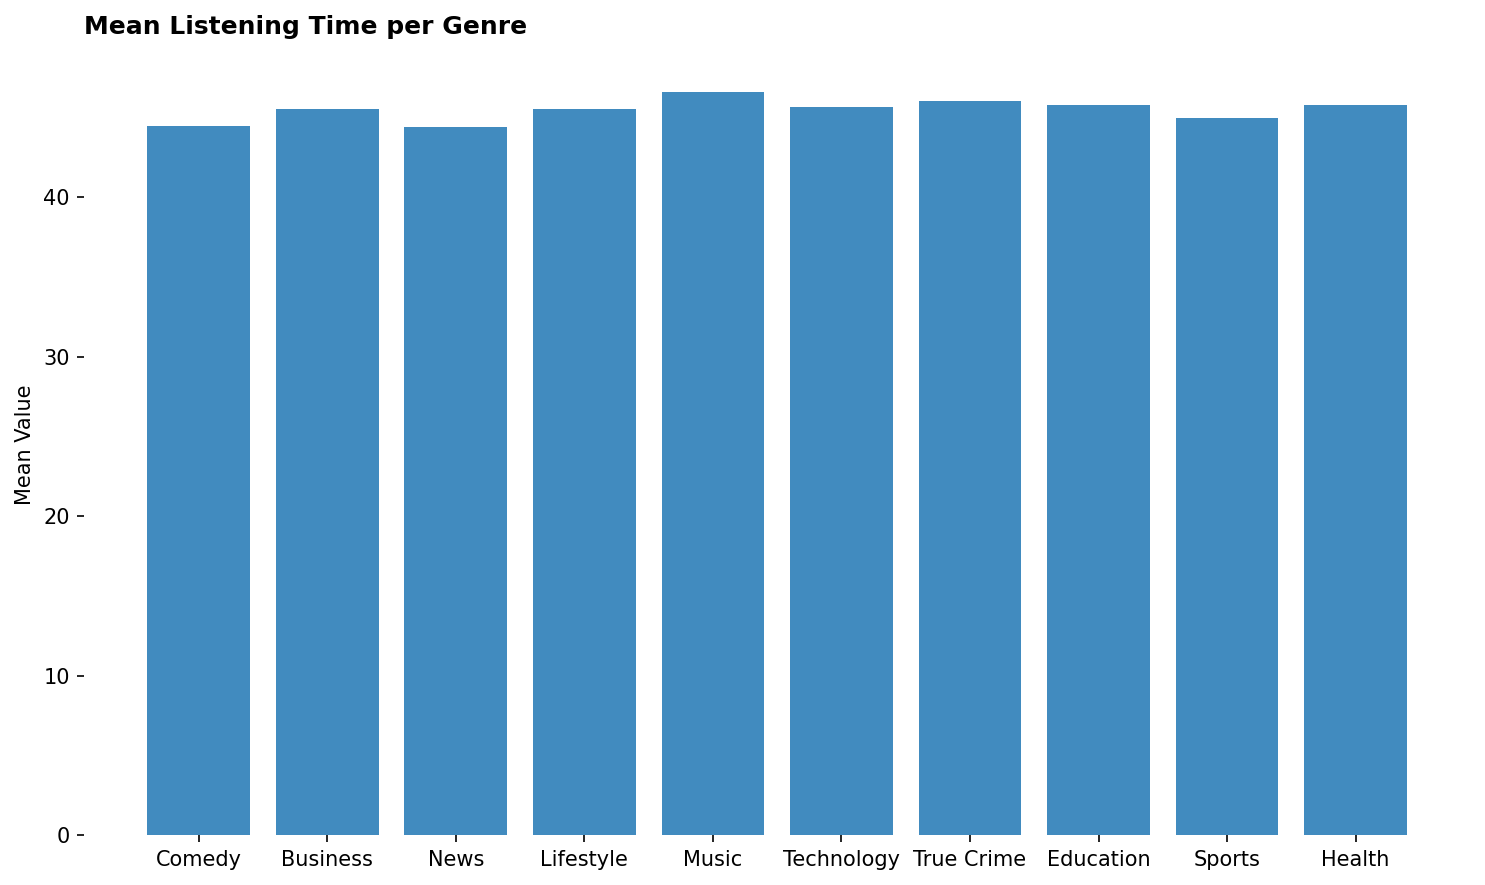

In [23]:
multiple_barplot(genres_and_counts["Genre"], genres_and_counts["Listening_Time_minutes"], "Mean Listening Time per Genre")

In [24]:
top_genres = genres_and_counts["Genre"]
# Create dict of lists per genre
data_by_genre = {
    genre: train.filter(pl.col("Genre") == genre)["Listening_Time_minutes"].to_list()
    for genre in top_genres
}

# Determine the maximum length
max_len = max(len(v) for v in data_by_genre.values())

# Pad all lists to max length with None
padded_data = {
    genre: values + [None] * (max_len - len(values))
    for genre, values in data_by_genre.items()
}

# Now create the DataFrame safely
wide = pl.DataFrame(padded_data)
wide

Comedy,Business,News,Lifestyle,Music,Technology,True Crime,Education,Sports,Health
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
88.01241,47.60142,22.37517,24.40379,45.94761,46.27824,31.41998,44.92531,74.08016,75.61031
29.2275,9.14796,68.00124,77.01387,103.56,50.93591,64.75024,42.89441,48.26043,22.77047
76.78874,94.61787,41.93243,16.79904,25.47053,63.97718,30.8951,6.67525,79.67749,25.38384
0.0,7.07583,57.4838,21.67971,101.19214,0.75783,38.8,34.71174,14.96035,53.46902
35.11072,14.58363,16.0494,7.21512,81.49839,89.71709,90.81754,23.54377,56.87222,53.58589
…,…,…,…,…,…,…,…,…,…
null,null,null,null,null,null,null,null,50.6487,null
null,null,null,null,null,null,null,null,24.10779,null
null,null,null,null,null,null,null,null,7.39197,null


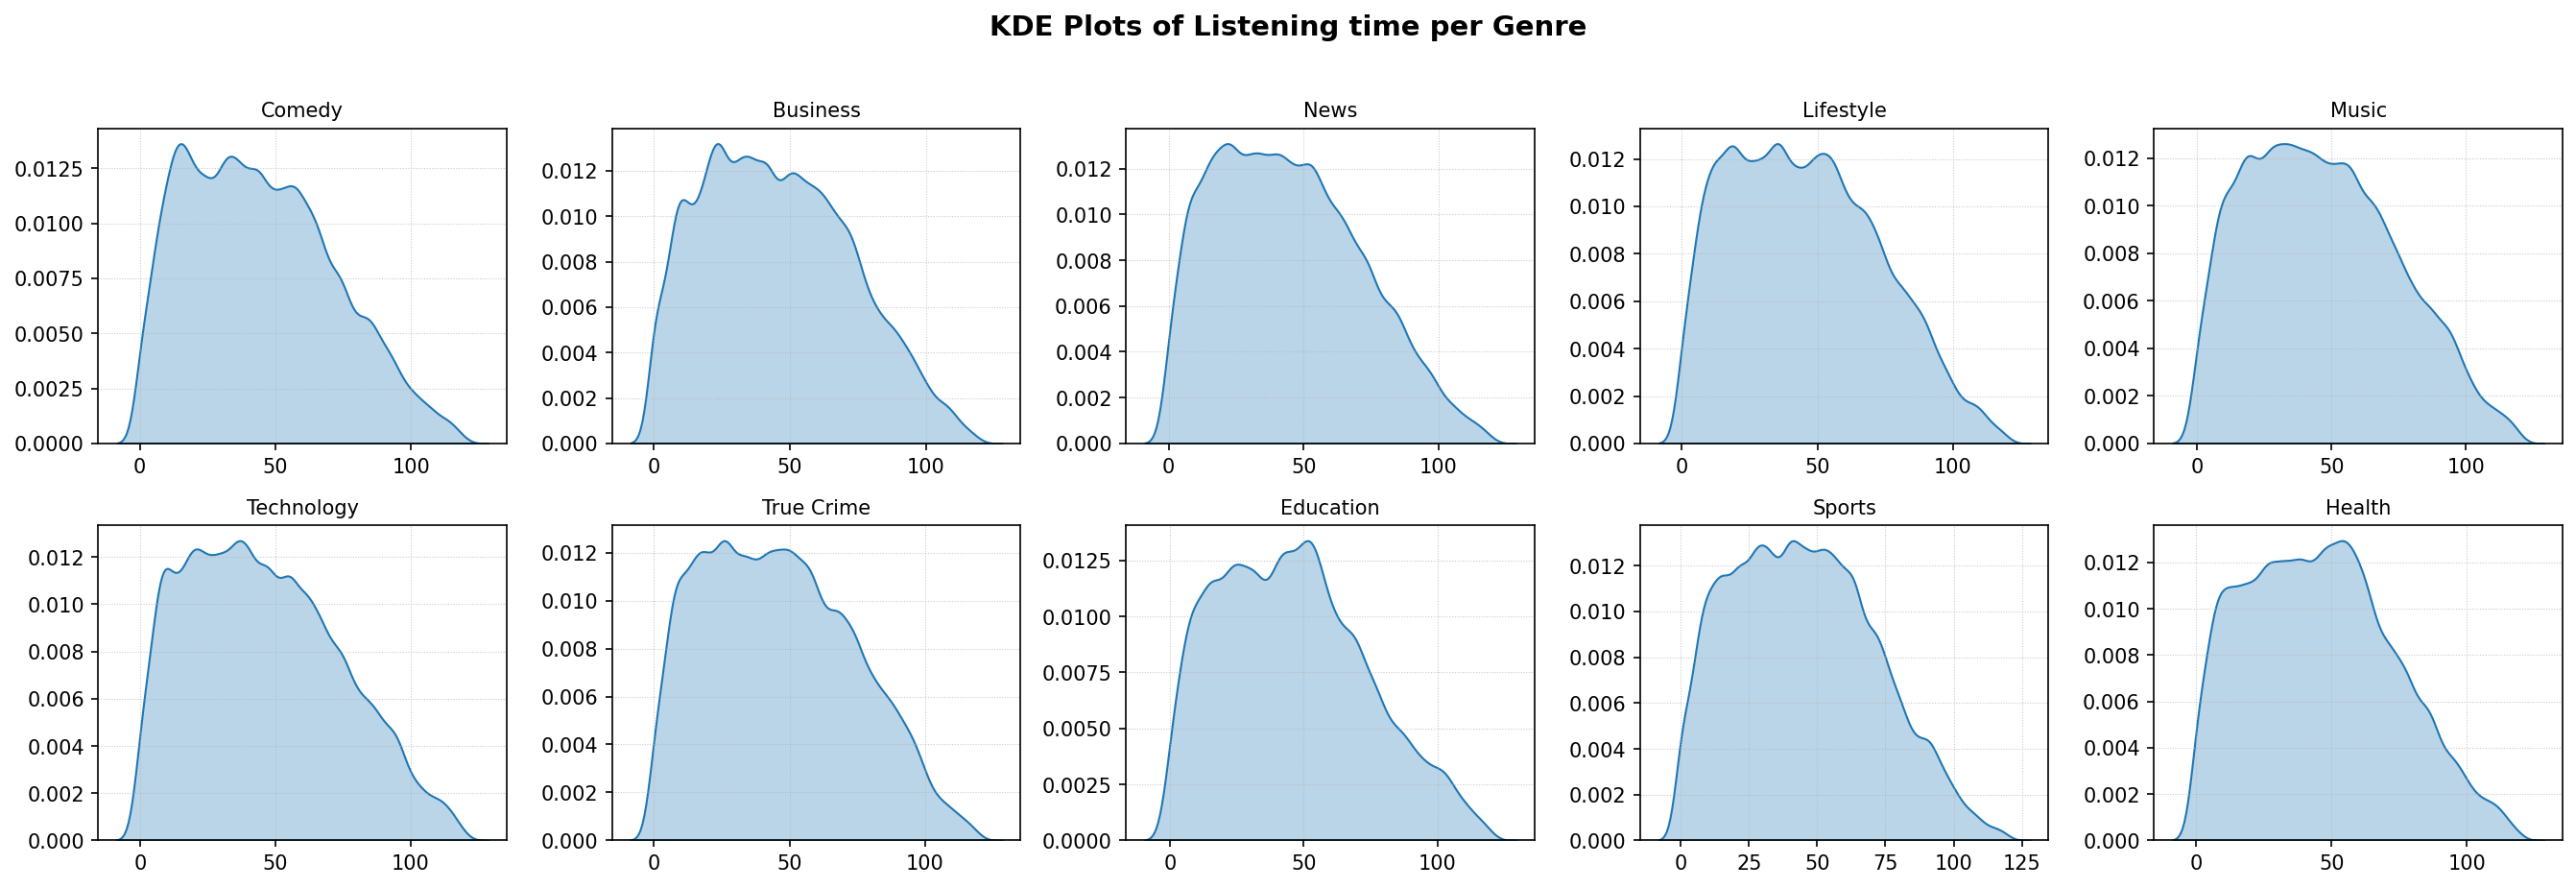

In [25]:
multiple_kde_plots(wide, genres_and_counts["Genre"], "KDE Plots of Listening time per Genre")

<Axes: xlabel='Episode_Length_minutes', ylabel='Listening_Time_minutes'>

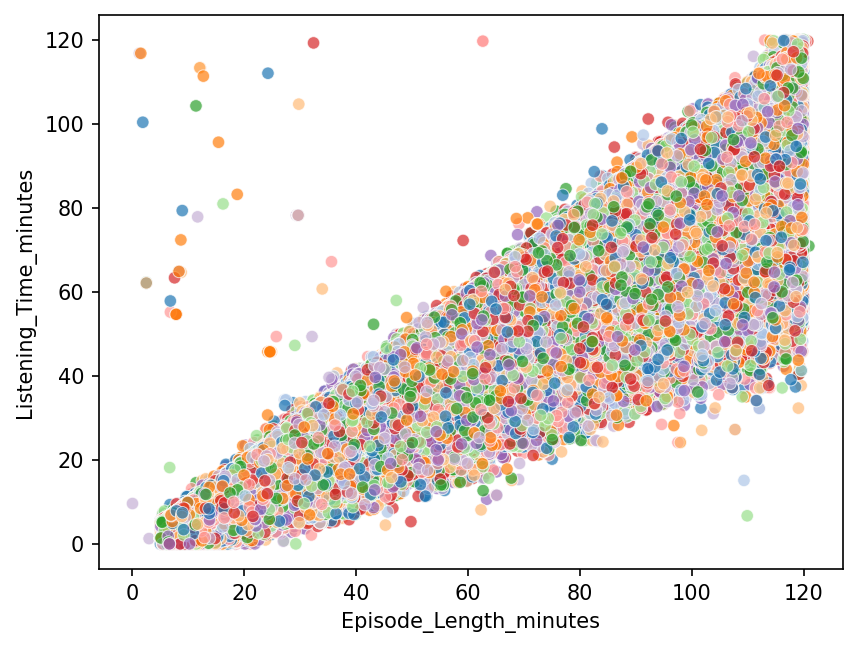

In [26]:
sns.scatterplot(
    data=ep_length_no_outlier.to_pandas(),
    x="Episode_Length_minutes",
    y="Listening_Time_minutes",
    hue="Genre",
    palette="tab20",  # nice categorical palette
    alpha=0.7,
    legend=False
)

Listening times seem roughly similar with no clear separation, which is to be expected from synthetic data, so I believe the genre will hardly be an indicator of listening tendency

## Listening Time per Podcast

In [27]:
train["Podcast_Name"].n_unique()

48

<Axes: xlabel='Episode_Length_minutes', ylabel='Listening_Time_minutes'>

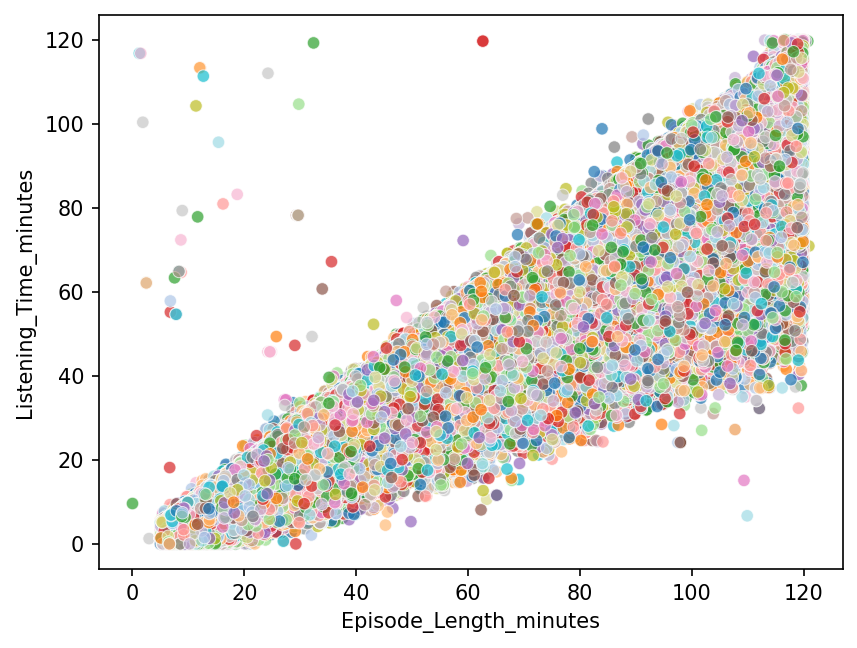

In [28]:
sns.scatterplot(
    data=ep_length_no_outlier.to_pandas(),
    x="Episode_Length_minutes",
    y="Listening_Time_minutes",
    hue="Podcast_Name",
    palette="tab20",  # nice categorical palette
    alpha=0.7,
    legend=False
)

There does not seem to be a pattern regarding each podcast and listening time, or podcast and episode lengths, even though it's a bit hard to see with 48 different podcasts

## Listening Time per Day posted

In [29]:
publication_days = train.unique("Publication_Day")["Publication_Day"]
publication_days

Publication_Day
str
"""Thursday"""
"""Tuesday"""
"""Friday"""
"""Wednesday"""
"""Monday"""
"""Sunday"""
"""Saturday"""


In [30]:
data_by_day = {
    day: train.filter(pl.col("Publication_Day") == day)["Listening_Time_minutes"].to_list()
    for day in publication_days
}

# Determine the maximum length
max_len = max(len(v) for v in data_by_day.values())

# Pad all lists to max length with None
padded_data = {
    genre: values + [None] * (max_len - len(values))
    for genre, values in data_by_day.items()
}

# Now create the DataFrame safely
wide_by_day = pl.DataFrame(padded_data)
wide_by_day

Thursday,Tuesday,Friday,Wednesday,Monday,Sunday,Saturday
f64,f64,f64,f64,f64,f64,f64
31.41998,44.92531,57.4838,50.93591,46.27824,64.75024,88.01241
22.37517,89.71709,6.67525,14.96035,75.61031,42.89441,22.77047
45.94761,25.47053,40.33025,29.2275,68.00124,0.75783,48.26043
74.08016,76.78874,19.28,47.60142,103.56,26.57501,41.93243
63.97718,71.17189,23.71495,99.15797,54.52628,53.58589,56.87222
…,…,…,…,…,…,…
null,null,null,null,null,59.74578,null
null,null,null,null,null,40.18565,null
null,null,null,null,null,50.44,null


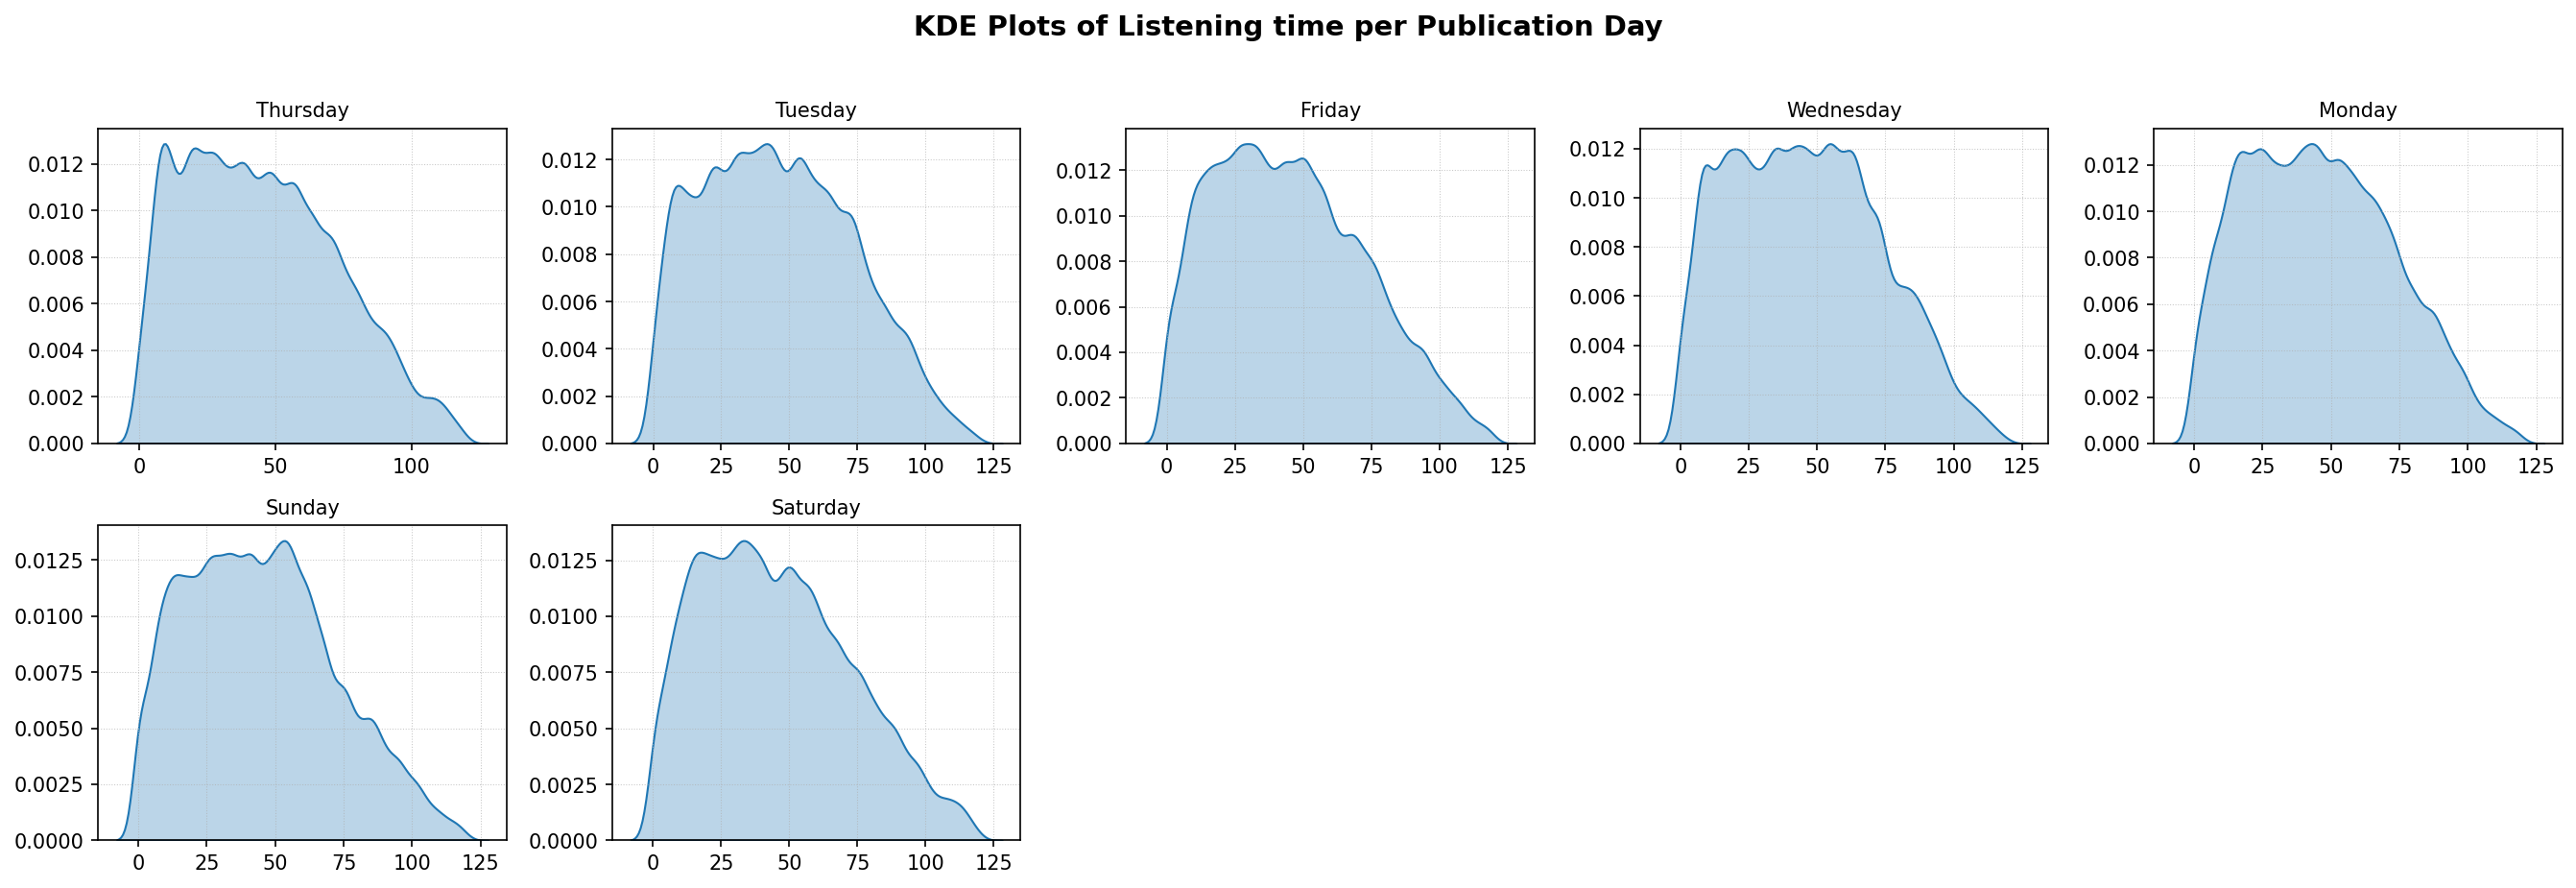

In [31]:
multiple_kde_plots(wide_by_day, publication_days, "KDE Plots of Listening time per Publication Day")

It seems that there also isn't a pattern on listening times per publication days

<Axes: xlabel='Episode_Length_minutes', ylabel='Listening_Time_minutes'>

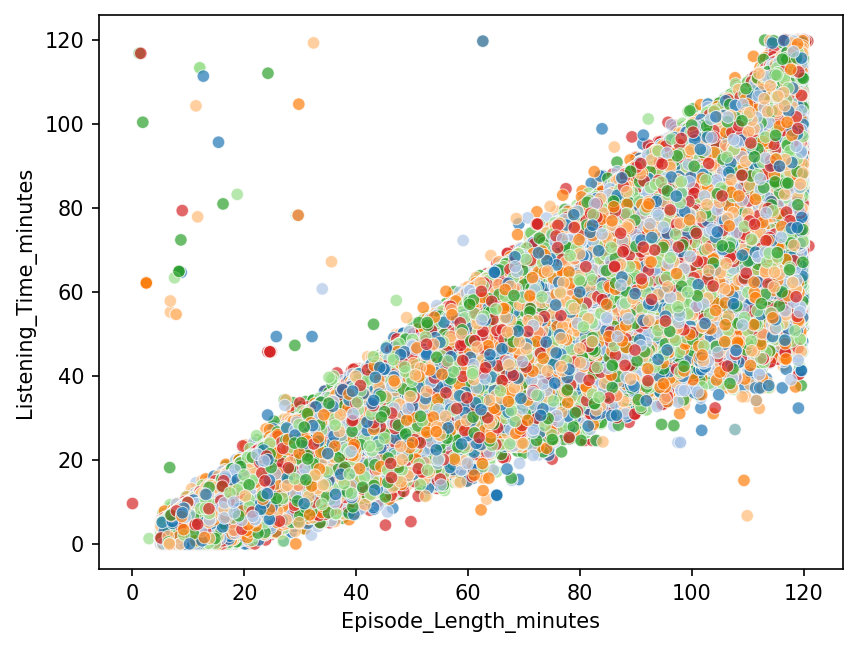

In [32]:
sns.scatterplot(
    data=ep_length_no_outlier.to_pandas(),
    x="Episode_Length_minutes",
    y="Listening_Time_minutes",
    hue="Publication_Day",
    palette="tab20",  # nice categorical palette
    alpha=0.7,
    legend=False
)

## Listening Time and Sentiment

In [33]:
train["Episode_Sentiment"].unique()

Episode_Sentiment
str
"""Positive"""
"""Negative"""
"""Neutral"""


<Axes: xlabel='Episode_Length_minutes', ylabel='Listening_Time_minutes'>

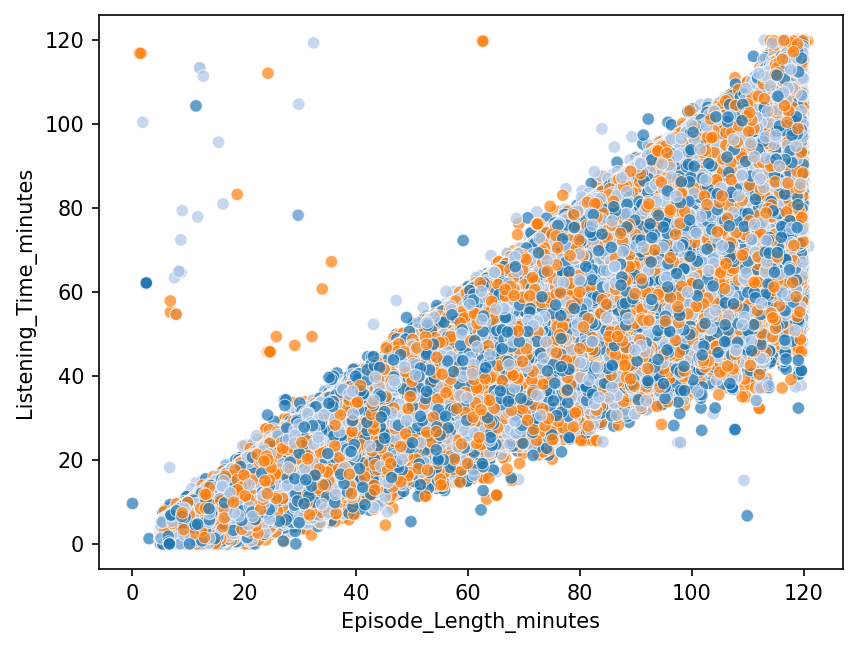

In [34]:
sns.scatterplot(
    data=ep_length_no_outlier.to_pandas(),
    x="Episode_Length_minutes",
    y="Listening_Time_minutes",
    hue="Episode_Sentiment",
    palette="tab20",  # nice categorical palette
    alpha=0.7,
    legend=False
)

Also no Patterns here

## Listening Time and Time Posted

<Axes: xlabel='Episode_Length_minutes', ylabel='Listening_Time_minutes'>

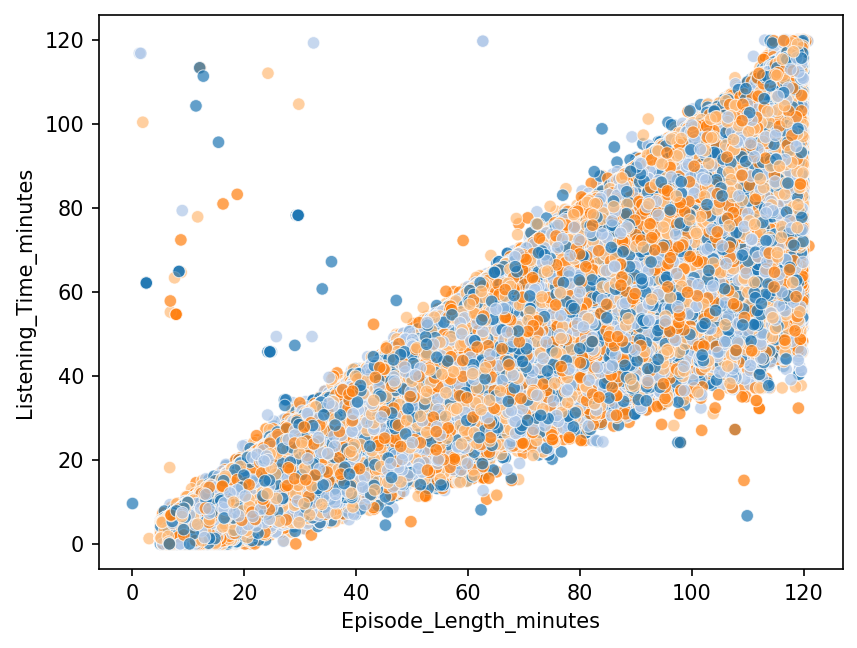

In [35]:
sns.scatterplot(
    data=ep_length_no_outlier.to_pandas(),
    x="Episode_Length_minutes",
    y="Listening_Time_minutes",
    hue="Publication_Time",
    palette="tab20",  # nice categorical palette
    alpha=0.7,
    legend=False
)

Also no patterns here